# Taller 04: Descubriendo Patrones Musicales con Spotify

**Caso:** Como Data Scientist de una plataforma de streaming, se busca agrupar las canciones más populares del 2023 usando únicamente sus características de audio (sin usar género ni artista), para apoyar al sistema de recomendación con nuevas etiquetas descubiertas mediante Clustering.

**Dataset:** `spotifydataset.csv` — 999 canciones con características de audio (Kaggle: *Spotify Songs and Artists Dataset*).

## Bloque 1: Configuración y Carga de Datos

In [19]:
# 1. Importación de Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "6"  

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

In [20]:
# Carga del dataset
df = pd.read_csv("spotifydataset.csv")

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1000 filas x 23 columnas


,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   artist_name        1000 non-null   object 
 2   genres             837 non-null    object 
 3   followers          1000 non-null   int64  
 4   artist_popularity  1000 non-null   int64  
 5   artist_url         1000 non-null   object 
 6   track_name         1000 non-null   object 
 7   album_name         1000 non-null   object 
 8   release_date       1000 non-null   object 
 9   duration_ms        1000 non-null   int64  
 10  explicit           1000 non-null   bool   
 11  track_popularity   1000 non-null   int64  
 12  danceability       1000 non-null   float64
 13  energy             1000 non-null   float64
 14  key                1000 non-null   int64  
 15  loudness           1000 non-null   float64
 16  mode               1000 n

## Bloque 2: Limpieza y Preparación

Se trabaja únicamente con las columnas que describen las características auditivas de la canción, evitando `artist_name` y `genres` para no sesgar la agrupación.

In [22]:
audio_cols = [
    "track_popularity", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]

audio_df = df[audio_cols].copy()
audio_df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,1000.0,59.429000,23.884963,0.000000,57.000000,67.000000,74.000000,92.000
danceability,1000.0,0.611430,0.167246,0.069000,0.505500,0.634000,0.728250,0.964
energy,1000.0,0.660562,0.207568,0.003540,0.539500,0.680500,0.820000,0.998
key,1000.0,5.243000,3.613725,0.000000,2.000000,5.000000,9.000000,11.000
loudness,1000.0,-7.160373,4.479642,-39.482000,-8.334250,-5.943500,-4.582500,0.273
mode,1000.0,0.613000,0.487307,0.000000,0.000000,1.000000,1.000000,1.000
speechiness,1000.0,0.091402,0.090441,0.023200,0.037975,0.054800,0.106000,0.874
acousticness,1000.0,0.265840,0.288895,0.000005,0.028325,0.152500,0.416250,0.996
instrumentalness,1000.0,0.074700,0.225472,0.000000,0.000000,0.000004,0.000586,0.972
liveness,1000.0,0.188810,0.145454,0.026000,0.095700,0.129000,0.246500,0.984


In [23]:
# Revisión de valores nulos
print("Valores nulos por columna:")
print(audio_df.isnull().sum())

# Revisión de duplicados (canciones con exactamente las mismas características de audio)
n_dup = audio_df.duplicated().sum()
print(f"\nFilas duplicadas (mismas características de audio): {n_dup}")

Valores nulos por columna:
track_popularity    0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

Filas duplicadas (mismas características de audio): 7


In [24]:
# Eliminamos duplicados para que no distorsionen los clusters,
# y mantenemos el dataframe original (df_clean) alineado con audio_df
mask_unique = ~audio_df.duplicated()
df_clean = df.loc[mask_unique].reset_index(drop=True)
audio_df = audio_df.loc[mask_unique].reset_index(drop=True)

print(f"Dataset final: {audio_df.shape[0]} canciones, {audio_df.shape[1]} variables de audio")

Dataset final: 993 canciones, 12 variables de audio


In [25]:
# Estandarización de variables (media 0, desviación 1)
# Es indispensable porque las variables tienen escalas muy distintas
# (ej. tempo ~50-200 vs valence ~0-1), y K-Means/PCA usan distancias euclidianas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(audio_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=audio_cols)
X_scaled_df.describe().T[["mean", "std"]].round(3)

,mean,std
track_popularity,-0.0,1.001
danceability,0.0,1.001
energy,-0.0,1.001
key,0.0,1.001
loudness,0.0,1.001
mode,-0.0,1.001
speechiness,0.0,1.001
acousticness,0.0,1.001
instrumentalness,0.0,1.001
liveness,-0.0,1.001


## Bloque 3: Reducción de Dimensionalidad (PCA)

Reducimos las 12 variables estandarizadas a 2 componentes principales para poder visualizar los clusters en un plano 2D.

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {var_exp[1]*100:.2f}%")
print(f"Varianza total explicada por ambos componentes: {var_exp.sum()*100:.2f}%")

Varianza explicada por PC1: 24.92%
Varianza explicada por PC2: 12.74%
Varianza total explicada por ambos componentes: 37.65%


In [27]:
# Peso (loadings) de cada variable original en cada componente principal
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=audio_cols
).sort_values("PC1", ascending=False)

loadings.round(3)

,PC1,PC2
loudness,0.501,-0.116
energy,0.478,-0.285
danceability,0.255,0.525
valence,0.250,0.396
track_popularity,0.170,0.266
liveness,0.136,-0.306
speechiness,0.095,0.081
tempo,0.084,-0.376
key,0.031,0.123
mode,-0.057,-0.187


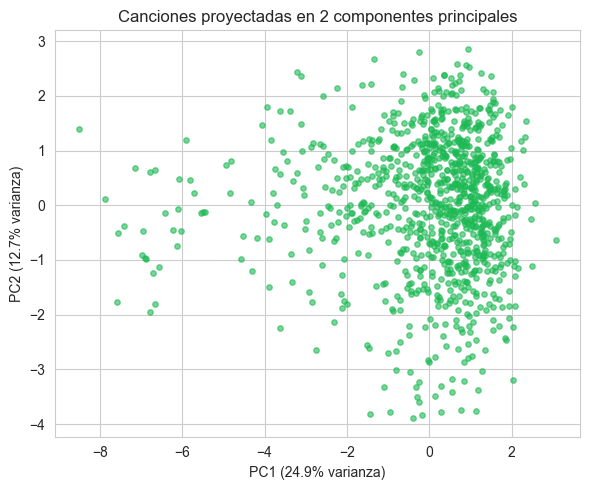

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=15, alpha=0.6, color="#1DB954")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza)")
ax.set_title("Canciones proyectadas en 2 componentes principales")
plt.tight_layout()
plt.show()

## Bloque 4: Modelado (Clustering)

Usamos **K-Means**. Para elegir el número óptimo de clusters (*k*) combinamos el **método del codo** (inercia) con el **coeficiente de silueta**, calculados sobre los datos estandarizados (no sobre las 2 componentes de PCA, para no perder información en la decisión de k).

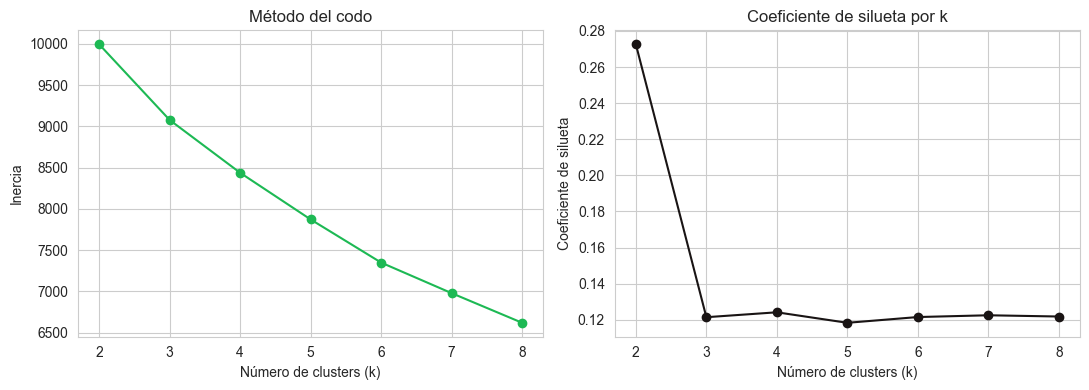

In [29]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="#1DB954")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del codo")

axes[1].plot(list(k_range), silhouettes, marker="o", color="#191414")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Coeficiente de silueta por k")

plt.tight_layout()
plt.show()

**Elección de k:** el coeficiente de silueta más alto se da en k=2, pero ese valor produce una separación demasiado gruesa (básicamente "energéticas vs. tranquilas") con poco valor para un sistema de recomendación. A partir de k=4 la curva de silueta se estabiliza y el codo de la inercia se suaviza, mientras que k=4 produce grupos claramente diferenciables e interpretables en el Bloque 5. Por eso se elige **k = 4** como mejor equilibrio entre calidad estadística e interpretabilidad de negocio.

In [30]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, cluster_labels)
print(f"k = {k_final} | Coeficiente de silueta = {sil_final:.3f}")

df_clean["cluster"] = cluster_labels
audio_df["cluster"] = cluster_labels

df_clean["cluster"].value_counts().sort_index()

k = 4 | Coeficiente de silueta = 0.124


cluster
0    326
1     58
2    165
3    444
Name: count, dtype: int64

**Comparación con DBSCAN** (referencia): a diferencia de K-Means, DBSCAN no requiere fijar k, pero sí es sensible a `eps` y suele marcar como "ruido" (-1) canciones atípicas en vez de forzarlas a un grupo.

In [31]:
from sklearn.neighbors import NearestNeighbors

# Estimación simple de eps con la distancia al k-ésimo vecino más cercano
neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

eps_guess = np.percentile(distances, 90)
print(f"eps sugerido (percentil 90 de distancias al 5º vecino): {eps_guess:.2f}")

dbscan = DBSCAN(eps=eps_guess, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN: {n_clusters_db} clusters encontrados, {n_noise} puntos marcados como ruido")

eps sugerido (percentil 90 de distancias al 5º vecino): 2.95
DBSCAN: 3 clusters encontrados, 47 puntos marcados como ruido


DBSCAN encuentra una estructura mucho menos clara para este dataset (pocos clusters densos y/o mucho ruido), por lo que se mantiene **K-Means con k=4** como modelo principal para la interpretación.

## Bloque 5: Visualización y Análisis

Interpretamos qué representa cada uno de los 4 grupos encontrados.

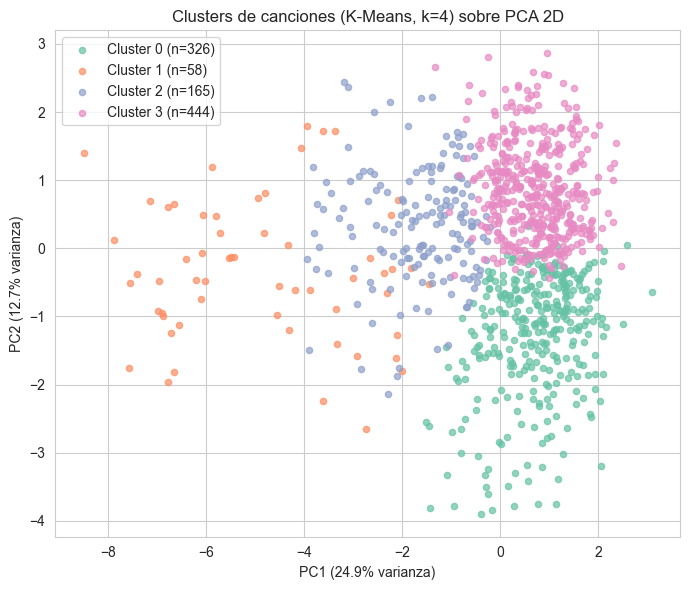

In [32]:
df_clean["PC1"] = X_pca[:, 0]
df_clean["PC2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
palette = sns.color_palette("Set2", k_final)

for c in sorted(df_clean["cluster"].unique()):
    subset = df_clean[df_clean["cluster"] == c]
    ax.scatter(subset["PC1"], subset["PC2"], s=20, alpha=0.7,
               color=palette[c], label=f"Cluster {c} (n={len(subset)})")

ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}% varianza)")
ax.set_title(f"Clusters de canciones (K-Means, k={k_final}) sobre PCA 2D")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Perfil promedio de cada cluster en las variables de audio originales (sin escalar)
cluster_profile = df_clean.groupby("cluster")[audio_cols].mean().round(3)
cluster_profile

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,,,,
0,56.021,0.520,0.811,4.828,-5.137,0.739,0.089,0.092,0.062,0.277,0.453,136.674
1,41.224,0.434,0.299,4.655,-18.886,0.603,0.051,0.752,0.830,0.117,0.316,113.218
2,50.800,0.535,0.430,5.648,-9.914,0.745,0.080,0.604,0.025,0.148,0.399,115.404
3,67.221,0.729,0.682,5.475,-6.126,0.473,0.102,0.203,0.005,0.149,0.632,115.450


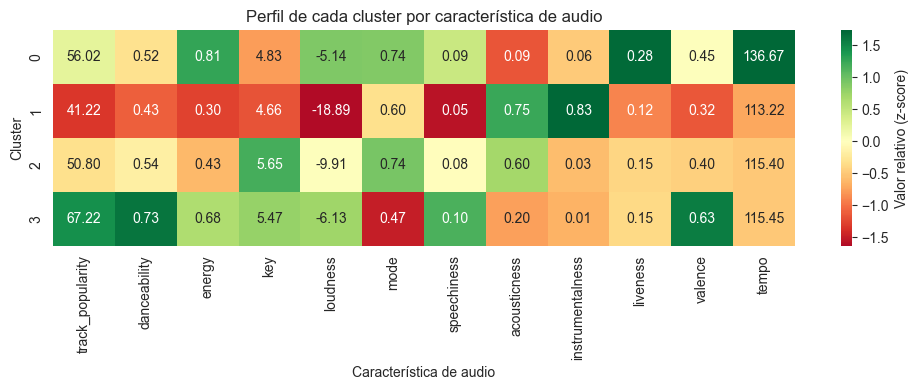

In [34]:
# Heatmap del perfil de cada cluster, estandarizado para comparar variables entre sí
profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=audio_cols,
    index=cluster_profile.index
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(profile_scaled, annot=cluster_profile.values, fmt=".2f",
            cmap="RdYlGn", center=0, cbar_kws={"label": "Valor relativo (z-score)"}, ax=ax)
ax.set_title("Perfil de cada cluster por característica de audio")
ax.set_xlabel("Característica de audio")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

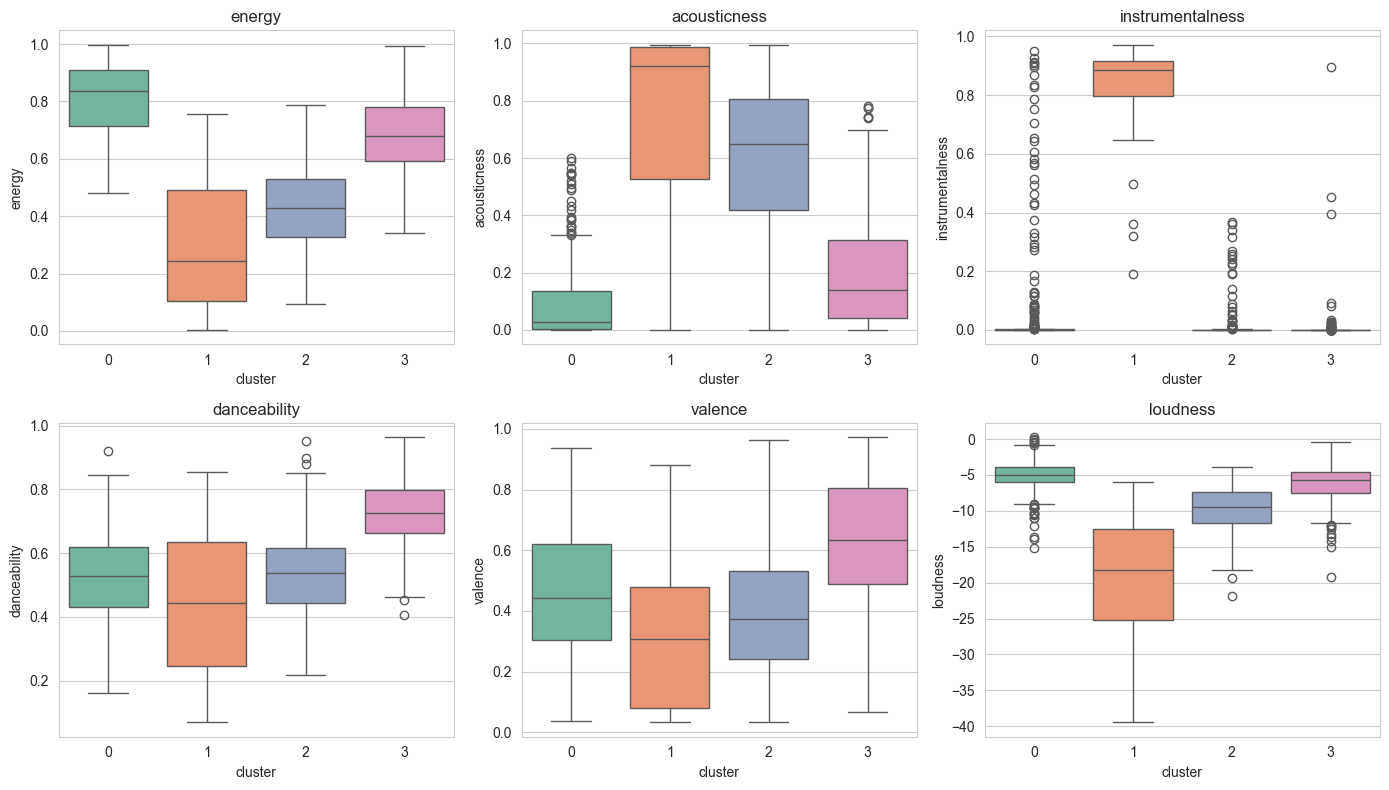

In [35]:
# Boxplots de las variables más relevantes para diferenciar los clusters
key_vars = ["energy", "acousticness", "instrumentalness", "danceability", "valence", "loudness"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, var in zip(axes, key_vars):
    sns.boxplot(data=df_clean, x="cluster", y=var, hue="cluster",
                palette=palette, legend=False, ax=ax)
    ax.set_title(var)

plt.tight_layout()
plt.show()

In [36]:
# Popularidad promedio por cluster: ¿algún grupo tiende a ser más "hit" que otro?
pop_by_cluster = df_clean.groupby("cluster")["track_popularity"].agg(["mean", "median", "count"]).round(1)
pop_by_cluster

,mean,median,count
cluster,,,
0,56.0,65.0,326
1,41.2,54.5,58
2,50.8,64.0,165
3,67.2,70.0,444


### Interpretación de los clusters

| Cluster | Perfil de audio | Etiqueta propuesta |
|---|---|---|
| **0** | Energy y loudness muy altos, tempo alto, acousticness/instrumentalness bajos | **Alta energía / sonido tipo rock-pop** |
| **1** | Loudness muy bajo, acousticness e instrumentalness muy altos, energy bajo, popularidad más baja | **Acústico e instrumental, bajo perfil** |
| **2** | Valores intermedios en casi todo, acousticness moderado-alto | **Acústico ligero / medio tiempo** |
| **3** | Mayor danceability, valence y popularidad; energy medio-alto | **Pop bailable y popular (hits)** |

(Los números exactos de cada perfil están en la tabla e imagen del Bloque 5; las etiquetas son la interpretación cualitativa de esos patrones.)

## Conclusiones

1. **Las características de audio, sin usar género ni artista, sí permiten segmentar canciones en grupos musicalmente coherentes.** El clustering con K-Means (k=4) separó las canciones en perfiles claramente distintos —energéticas, acústicas/instrumentales, de energía media y pop bailable popular— confirmando que variables como `energy`, `acousticness`, `instrumentalness` y `danceability` capturan patrones reales de "sonido", útiles para un sistema de recomendación basado en similitud sonora y no solo en metadatos.

2. **El cluster de canciones "pop bailable y popular" (Cluster 3) concentra la mayor popularidad promedio**, sugiriendo que las combinaciones de alta *danceability*, *valence* alto (canciones más "alegres") y energía media-alta están asociadas a mayor éxito comercial en este conjunto de canciones top del 2023, mientras que el cluster acústico/instrumental (Cluster 1) es el más pequeño y el de menor popularidad promedio.

3. **El número óptimo de clusters no siempre es el que maximiza una métrica estadística por sí sola.** Aunque el coeficiente de silueta era más alto con k=2, ese resultado era demasiado general (esencialmente "alta energía vs. baja energía") y de poco valor práctico; k=4 ofrece un balance mejor entre validez estadística (silueta e inercia razonables) e interpretabilidad de negocio, mostrando que la elección de k debe combinar evidencia cuantitativa con el objetivo del análisis.